In [ ]:
#preprocesamiento de datos para machine learning
Objetivo: Aplicar las principales tecnicas de preprocesamiento de datos para un Dataset antes de entrenar un modelo de IA 

Problema: Se desea construir un modelo de capaz de predecir si un pasajero sobrevivio o no al hundimiento del Titanic 

In [1]:
import pandas as pd 
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import kagglehub

C:\Users\estra\anaconda3\envs\Extraccion9B\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
pip install kagglehub


   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   -------------------------- ------------- 2/3 [kagglehub]
   -------------------------- ------------- 2/3 [kagglehub]
   ---------------------------------------- 3/3 [kagglehub]

Note: you may need to restart the kernel to use updated packages.


In [5]:
path = kagglehub.dataset_download("yasserh/titanic-dataset")

100%|██████████| 22.0k/22.0k [00:00<00:00, 441kB/s]

Extracting files...


In [6]:
print("Ruta del dataset", path)

Ruta del dataset C:\Users\estra\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1


In [7]:
dfTitanic = pd.read_csv(path + "/Titanic-Dataset.csv")

In [8]:
dfTitanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
dfTitanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Parte 1, Compresion del problema
Determinar si sobreviven al hundimiento del titanic, con base en la informacion obtenida
Survived 
0- No sobrevivio 
1- Sobrevivio 

In [11]:
dfTitanic["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

AttributeError: module 'matplotlib.pyplot' has no attribute 'tittle'

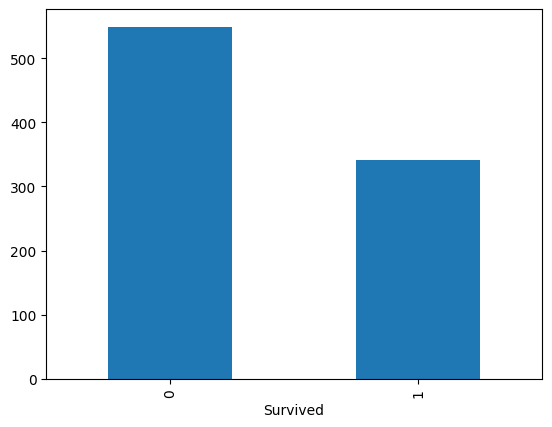

In [13]:
#Graficamos
dfTitanic["Survived"].value_counts().plot(
    kind="bar"
)
plt.tittle("Distribucion de supervivencia")
plt.show()

In [14]:
dfTitanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [17]:
#Hipotesis inicial
dfTitanic.groupby(
    "Sex"
)["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [21]:
dfTitanic.groupby(
    "Pclass"
)["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [25]:
dfTitanic.groupby(
    "Fare"
)["Survived"].mean()

Fare
0.0000      0.066667
4.0125      0.000000
5.0000      0.000000
6.2375      0.000000
6.4375      0.000000
              ...   
227.5250    0.750000
247.5208    0.500000
262.3750    1.000000
263.0000    0.500000
512.3292    1.000000
Name: Survived, Length: 248, dtype: float64

## Parte 3. Correlacion e Hipotesis
Creamos una matriz de correlacion para identificar la relacion lineal entre variables. NO identifica la 
importancia real de variables en el modelo

In [26]:
variables_numericas = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

In [27]:
corr = dfTitanic[variables_numericas].corr()

In [28]:
corr

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

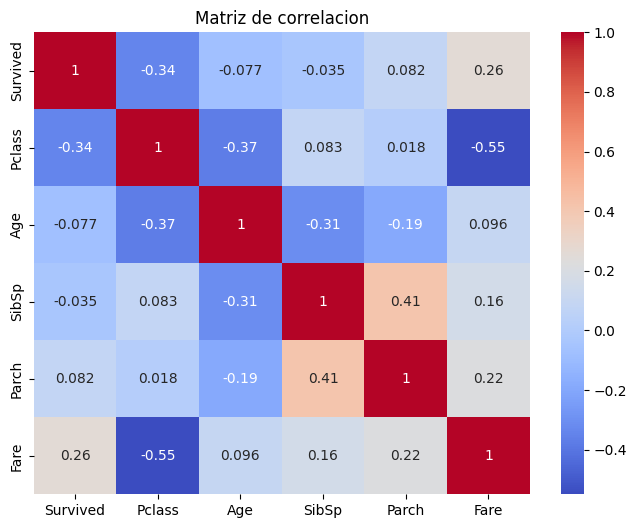

In [31]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de correlacion")
plt.show

# Parte 4. Seleccion de variables Predictoras y variable objetivo
X = Variables que utilizara el modelo
y = Variable que queremos predecir

In [32]:
columnas = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Fare",
    "Embarked"
]

In [99]:
#Definimos x y 
x = dfTitanic[columnas]
y = dfTitanic["Survived"]

In [42]:
print(X.columns.tolist())

['Pclass', 'Sex', 'Age', 'SibSp', 'Fare', 'Embarked']


In [43]:
print(y.name)

Survived


# Parte 5. Tratamiento de los valores

Para simplificar el proceso, realizaremos la imputacion de los datos antes de la separacion Train/Test

In [44]:
#Revisamos las variables predictorias
X.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Fare        0
Embarked    0
dtype: int64

In [45]:
X["Age"] = X["Age"].fillna(
    X["Age"].median()
)

C:\Users\estra\AppData\Local\Temp\ipykernel_22956\2953535474.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Age"] = X["Age"].fillna(


In [40]:
X["Embarked"] = X["Embarked"].fillna(
    X["Embarked"].mode()[0]
)

C:\Users\estra\AppData\Local\Temp\ipykernel_22956\3303780736.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Embarked"] = X["Embarked"].fillna(


In [46]:
X.head()

,Pclass,Sex,Age,SibSp,Fare,Embarked
0,3,male,22.0,1,7.2500,S
1,1,female,38.0,1,71.2833,C
2,3,female,26.0,0,7.9250,S
3,1,female,35.0,1,53.1000,S
4,3,male,35.0,0,8.0500,S


#Parte 6. Escalado de los datos
Los algortimos no entienden texto, Se deben convertir las variables categoricas en variables numericas

In [47]:
X = pd.get_dummies(
    X,
    columns=["Sex","Embarked"],
    drop_first=True
)

In [48]:
X.head()

,Pclass,Age,SibSp,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,7.2500,True,False,True
1,1,38.0,1,71.2833,False,False,False
2,3,26.0,0,7.9250,False,False,True
3,1,35.0,1,53.1000,False,False,True
4,3,35.0,0,8.0500,True,False,True


#Parte 7. Particionamos los datos
No debemos entrenar y evaluar utilizando los mismos datos.

La recomendacion es:
Entrenamiento 80%
Pruebas 20%

In [91]:
x_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.20,
    random_state=42
)

In [61]:
print ("Entrenamiento:", x_train.shape)

Entrenamiento: (712, 6)


In [62]:
print ("Prueba: ", y_test.shape)

Prueba:  (179,)


# Parte 8. Escalado de las variables

Las variables numericas tienen valores distintos. El escalado evita que una variable domine mas que otra.

In [72]:
columnas_numericas = [
    "Age",
    "Fare",
    "SibSp",
]

In [80]:
X_train[columnas_numericas].describe()

NameError: name 'X_train' is not defined

In [108]:
X = dfTitanic[
    ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
].copy()

X = pd.get_dummies(
    X,
    columns=["Sex", "Embarked"],
    drop_first=True,
    dtype=int
)

In [74]:
scaler = StandardScaler()
x_train[columnas_numericas] = scaler.fit_transform(
    x_train[columnas_numericas]
)
x_test[columnas_numericas] = scaler.transform(
    x_test[columnas_numericas]
)

In [105]:
x_train[columnas_numericas].describe()

,Age,Fare,SibSp
count,572.000000,712.000000,712.000000
mean,29.498846,32.586276,0.553371
std,14.500059,51.969529,1.176404
min,0.420000,0.000000,0.000000
25%,21.000000,7.925000,0.000000
50%,28.000000,14.454200,0.000000
75%,38.000000,30.500000,1.000000
max,80.000000,512.329200,8.000000


In [109]:
modelo.fit(
    x_train,
    y_train
)

ValueError: could not convert string to float: 'male'

In [ ]:
#Parte 9. Entrenamiento de los datos

In [76]:
modelo = DecisionTreeClassifier (
    max_depth = 4,
    random_state=42
)

In [115]:
X["Age"] = X["Age"].fillna(X["Age"].median())
X["Fare"] = X["Fare"].fillna(X["Fare"].median())

In [119]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(random_state=42)

modelo.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [117]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#Parte 10. Evaluamos el modelo 

Realizamos predicciones para evaluar el modelo

In [127]:
predicciones = modelo.predict(
    X_test
)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Embarked
- Sex
Feature names seen at fit time, yet now missing:
- Embarked_Q
- Embarked_S
- Parch
- Sex_male


In [97]:
pd.DataFrame({
    "Real ": y_test,
    "Prediccion ": predicciones
}).head(15)

NameError: name 'predicciones' is not defined

#Parte 11. Evaluacion del modelo
El accuracy determinar el porcentaje de predicciones correctas realizadas por el modelo

In [126]:
accuracy = accuracy_score(
    y_test,
    predicciones
)

NameError: name 'predicciones' is not defined

In [121]:
import pandas as pd

columnas = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = dfTitanic[columnas].copy()
y = dfTitanic["Survived"]

In [122]:
X["Age"] = X["Age"].fillna(X["Age"].median())
X["Fare"] = X["Fare"].fillna(X["Fare"].median())
X["Embarked"] = X["Embarked"].fillna(X["Embarked"].mode()[0])

In [123]:
X = pd.get_dummies(
    X,
    columns=["Sex", "Embarked"],
    drop_first=True,
    dtype=int
)

In [124]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [125]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(random_state=42)

modelo.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [128]:
predicciones = modelo.predict(x_test)

In [129]:
from sklearn.metrics import accuracy_score

precision = accuracy_score(y_test, predicciones)

print("Precisión:", precision)

Precisión: 0.8212290502793296


|Accuracy| Interpretacion                  |
|--------|---------------------------------|
|50%     | adivina                         |
|60-70%  | Aceptable / Basico              |
|70-80%  | Bueno                           |
|80-90%  | Muy bueno                       |
|>90%    | Excelente ( posible sobreajuste)|